In [1]:
!rm -rf /content/drive/MyDrive/SentinelFatal2


# 02_pretrain.ipynb — SentinelFatal2 Pre-training Pipeline

**Agent 3 — Pre-training Pipeline (שלב 3)**  
Source: `src/train/pretrain.py`, `src/data/masking.py`, `src/data/dataset.py`  
SSOT: `docs/work_plan.md`, Part ה.4 + חלק ו שלב 3

---

## Notebook structure

| Cell | Purpose |
|------|----------|
| 1 | Setup: paths, seed, sys.path (+ Colab Drive mount) |
| 2 | GPU check |
| 3 | Load config + build model with PretrainingHead |
| 4 | **V3.1** Masking stability test — 10,000 seeds |
| 5 | **V3.2 + V3.3** Validate masking guarantees + loss on FHR only |
| 6 | **V3.4 + V3.5 + V3.6** Full pre-training (or dry-run) |
| 7 | Plot loss curves from logs/pretrain_loss.csv |

In [2]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────────
import sys, os, random
import numpy as np

# ── Colab: mount Drive, clone repo if needed, cd to project ───────────────────
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/SentinelFatal2'   # adjust if needed
    if not os.path.isdir(PROJECT_ROOT):
        print('Project folder not found on Drive — cloning from GitHub...')
        os.system(f'git clone https://github.com/ArielShamay/SentinelFatal2.git "{PROJECT_ROOT}"')
    os.chdir(PROJECT_ROOT)
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
else:
    # Local / VS Code
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    os.chdir(PROJECT_ROOT)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f'Project root : {os.getcwd()}')
print(f'Python       : {sys.version}')

Project root : c:\Users\ariel\Desktop\SentinelFatal2
Python       : 3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]


In [4]:
# ── Cell 1b: Download processed data (Colab only) ────────────────────────────
# The .npy data files are excluded from git; download from GitHub release.
import os, subprocess, zipfile, shutil

DATA_ZIP_URL = 'https://github.com/ArielShamay/SentinelFatal2/releases/download/data-v1/data_processed.zip'
DATA_ZIP     = 'data_processed.zip'
MARKER       = 'data/processed/ctu_uhb/1001.npy'

if IN_COLAB and not os.path.exists(MARKER):
    # Clean up any bad previous extraction (backslash artifacts)
    for bad in [f for f in os.listdir('data/processed') if '\\' in f]:
        p = os.path.join('data/processed', bad)
        if os.path.isdir(p):
            shutil.rmtree(p)
        else:
            os.remove(p)

    print('Downloading processed data from GitHub release...')
    subprocess.run(['wget', '-q', DATA_ZIP_URL, '-O', DATA_ZIP], check=True)
    with zipfile.ZipFile(DATA_ZIP) as z:
        print(f'  Archive: {len(z.namelist())} entries, first 3: {z.namelist()[:3]}')
        z.extractall('data/processed')
    os.remove(DATA_ZIP)

    n_ctu = len([f for f in os.listdir('data/processed/ctu_uhb') if f.endswith('.npy')])
    n_fhr = len([f for f in os.listdir('data/processed/fhrma') if f.endswith('.npy')])
    assert os.path.exists(MARKER), f'FAIL: {MARKER} not found'
    print(f'✓ Extracted {n_ctu + n_fhr} .npy files ({n_ctu} CTU-UHB + {n_fhr} FHRMA)')
else:
    print('Data files already present — skipping download.')

Data files already present — skipping download.


In [5]:
# ── Cell 2: GPU check ─────────────────────────────────────────────────────────
import torch
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'✓ GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    DEVICE = torch.device('cpu')
    print('⚠ No GPU found — running on CPU (training will be slow)')

print(f'torch {torch.__version__}  |  device: {DEVICE}')

⚠ No GPU found — running on CPU (training will be slow)
torch 2.10.0+cpu  |  device: cpu


In [6]:
# ── Cell 3: Load config + build model ─────────────────────────────────────────
from src.model.patchtst import PatchTST, load_config
from src.model.heads import PretrainingHead

CONFIG_PATH = 'config/train_config.yaml'
cfg = load_config(CONFIG_PATH)

model = PatchTST(cfg)
model.replace_head(PretrainingHead(
    d_model   = cfg['model']['d_model'],
    patch_len = cfg['data']['patch_len'],
))
model = model.to(DEVICE)

print(model)
print(f'Encoder params: {model.n_encoder_params:,}')
print(f'Head          : {type(model.head).__name__}')

PatchTST(patch=48@24, n_patches=73, d_model=128, head=PretrainingHead)
Encoder params: 413,056
Head          : PretrainingHead


In [7]:
# ── Cell 4: V3.1 — Masking stability test (10,000 seeds) ─────────────────────
from src.data.masking import apply_masking

N_SEEDS = 10_000
MASK_RATIO     = cfg['pretrain']['mask_ratio']
MIN_GROUP_SIZE = cfg['pretrain']['min_group_size']
MAX_GROUP_SIZE = cfg['pretrain']['max_group_size']
N_PATCHES      = cfg['data']['n_patches']   # 73
PATCH_LEN      = cfg['data']['patch_len']   # 48
TARGET_MASKED  = round(MASK_RATIO * N_PATCHES)  # 29

print(f'Testing {N_SEEDS:,} seeds  |  n_patches={N_PATCHES}, '
      f'mask_ratio={MASK_RATIO}, target_masked={TARGET_MASKED}')

dummy_patches = np.random.rand(N_PATCHES, PATCH_LEN).astype(np.float32)
failures = []

for seed in range(N_SEEDS):
    random.seed(seed)
    np.random.seed(seed)
    patches_copy = dummy_patches.copy()
    try:
        _, idx = apply_masking(
            patches_copy,
            mask_ratio=MASK_RATIO,
            min_group_size=MIN_GROUP_SIZE,
            max_group_size=MAX_GROUP_SIZE,
        )
        assert idx[0] >= 1,          f'seed={seed}: idx[0]={idx[0]} < 1 (boundary)'
        assert idx[-1] <= N_PATCHES - 2, f'seed={seed}: idx[-1]={idx[-1]} >= {N_PATCHES-1} (boundary)'
        assert len(idx) == TARGET_MASKED, f'seed={seed}: len(idx)={len(idx)} != {TARGET_MASKED}'
    except Exception as e:
        failures.append((seed, str(e)))

if failures:
    print(f'✗ {len(failures)} failures (first 5):')
    for s, e in failures[:5]:
        print(f'  seed={s}: {e}')
else:
    print(f'✓ V3.1 PASS — {N_SEEDS:,} seeds passed, masking is stable')

Testing 10,000 seeds  |  n_patches=73, mask_ratio=0.4, target_masked=29
✓ V3.1 PASS — 10,000 seeds passed, masking is stable


In [8]:
# ── Cell 5: V3.2 + V3.3 — Masking guarantees + loss on FHR only ──────────────
import torch.nn.functional as F
from src.train.pretrain import pretrain_step, generate_mask_indices

BATCH = 4
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

x = torch.randn(BATCH, 2, 1800, device=DEVICE)

# V3.2 — masking guarantees
mask_indices = generate_mask_indices(
    n_patches=N_PATCHES, mask_ratio=MASK_RATIO,
    min_group_size=MIN_GROUP_SIZE, max_group_size=MAX_GROUP_SIZE,
)
mask_arr = np.zeros(N_PATCHES, dtype=bool)
mask_arr[mask_indices] = True

# Boundary preservation
assert not mask_arr[0],  'FAIL V3.2: first patch is masked'
assert not mask_arr[-1], 'FAIL V3.2: last patch is masked'

# Correct count
assert len(mask_indices) == TARGET_MASKED, \
    f'FAIL V3.2: got {len(mask_indices)} masked patches, expected {TARGET_MASKED}'

# Every contiguous group ≥ min_group_size
diff = np.diff(np.concatenate([[0], mask_arr.astype(int), [0]]))
run_starts = np.where(diff == 1)[0]
run_ends   = np.where(diff == -1)[0]
for s, e in zip(run_starts, run_ends):
    assert (e - s) >= MIN_GROUP_SIZE, \
        f'FAIL V3.2: group of length {e-s} < {MIN_GROUP_SIZE} at position {s}'

print(f'✓ V3.2 PASS — boundary={not mask_arr[0] and not mask_arr[-1]}, '
      f'n_masked={len(mask_indices)}, n_groups={len(run_starts)}, '
      f'group_sizes={[int(e-s) for s,e in zip(run_starts, run_ends)][:8]}...')

# V3.3 — loss computed on FHR masked patches ONLY (not UC)
model.eval()
with torch.no_grad():
    pred, target = pretrain_step(model, x, mask_indices)

assert pred.shape   == (BATCH, TARGET_MASKED, PATCH_LEN), \
    f'FAIL V3.3: pred shape {pred.shape}'
assert target.shape == (BATCH, TARGET_MASKED, PATCH_LEN), \
    f'FAIL V3.3: target shape {target.shape}'

loss = F.mse_loss(pred, target)
assert loss.item() > 0, 'FAIL V3.3: loss is zero (suspicious)'
assert not torch.isnan(loss), 'FAIL V3.3: loss is NaN'

print(f'✓ V3.3 PASS — loss={loss.item():.6f} on ({BATCH}, {TARGET_MASKED}, {PATCH_LEN}) '
      f'masked FHR patches only')
model.train()

✓ V3.2 PASS — boundary=True, n_masked=29, n_groups=9, group_sizes=[2, 2, 3, 3, 4, 2, 4, 3]...
✓ V3.3 PASS — loss=1.182770 on (4, 29, 48) masked FHR patches only


PatchTST(patch=48@24, n_patches=73, d_model=128, head=PretrainingHead)

In [9]:
# ── Cell 6: V3.4 + V3.5 + V3.6 — Full Pre-training ───────────────────────────
#
# Set DRY_RUN = True (default) to run 2 batches only (CPU verification).
# Set DRY_RUN = False + DEVICE = cuda for the full Colab training run.
#
# NOTE: Calls pretrain() directly (not via subprocess) so that:
#   1. Errors surface immediately with full traceback
#   2. Print output streams in real-time
#   3. Dataset loading issues are never hidden
#
from src.train.pretrain import pretrain

DRY_RUN    = False       # ← Full training on Colab GPU
BATCH_SIZE = 4 if DRY_RUN else None   # None = use config default (64)
MAX_BATCHES = 2 if DRY_RUN else 0

if DRY_RUN:
    print(f'[dry-run] Running 2 batches on {DEVICE} ...')

pretrain(
    config_path='config/train_config.yaml',
    device_str=str(DEVICE),
    batch_size=BATCH_SIZE,
    max_batches=MAX_BATCHES,
)

if DRY_RUN:
    print('\n✓ V3.4 PASS — forward→backward→step completed without errors')
else:
    print('\n✓ Full pre-training complete')

[pretrain] device=cpu, batch_size=64, max_batches=full
[PretrainDataset] Loaded 687/687 recordings → 13687 windows (stride=900)
[pretrain] dataset - train windows=12319, val windows=1368
[pretrain] model: PatchTST(patch=48@24, n_patches=73, d_model=128, head=PretrainingHead)
[pretrain] encoder params: 413,056
[pretrain] Starting training: max_epochs=200, patience=10
  [train batch 1] loss=0.658145
  [train batch 2] loss=0.608818
  [train batch 3] loss=0.548855
  [train batch 4] loss=0.524089
  [train batch 5] loss=0.502094
  [train batch 6] loss=0.471020
  [train batch 7] loss=0.442748
  [train batch 8] loss=0.420259
  [train batch 9] loss=0.432995
  [train batch 10] loss=0.336907
  [train batch 11] loss=0.357354
  [train batch 12] loss=0.333653
  [train batch 13] loss=0.324304
  [train batch 14] loss=0.287889
  [train batch 15] loss=0.276075
  [train batch 16] loss=0.294222
  [train batch 17] loss=0.274898
  [train batch 18] loss=0.256683
  [train batch 19] loss=0.251767
  [train batc

In [ ]:
# ── Cell 6b: Verify artifacts (V3.5 checkpoint, V3.6 early stopping log) ─────
import os

# V3.5 — checkpoint saved
ckpt_path = 'checkpoints/pretrain/epoch_000.pt'
best_path = 'checkpoints/pretrain/best_pretrain.pt'
assert os.path.exists(ckpt_path), f'FAIL V3.5: checkpoint not found at {ckpt_path}'
assert os.path.exists(best_path), f'FAIL V3.5: best checkpoint not found at {best_path}'

# Verify checkpoint loads correctly
loaded = torch.load(best_path, map_location='cpu', weights_only=True)
assert isinstance(loaded, dict), 'FAIL V3.5: checkpoint is not a state dict'
print(f'✓ V3.5 PASS — checkpoints saved ({len(loaded)} param tensors)')

# V3.6 — loss CSV logged
log_path = 'logs/pretrain_loss.csv'
assert os.path.exists(log_path), f'FAIL V3.6: log not found at {log_path}'
import csv
with open(log_path) as f:
    rows = list(csv.DictReader(f))
assert len(rows) >= 1, 'FAIL V3.6: no rows in loss CSV'
assert 'train_loss' in rows[0] and 'val_loss' in rows[0], 'FAIL V3.6: missing columns'
print(f'✓ V3.6 PASS — loss CSV has {len(rows)} row(s): {rows[0]}')

✓ V3.5 PASS — checkpoints saved (59 param tensors)
✓ V3.6 PASS — loss CSV has 16 row(s): {'epoch': '0', 'train_loss': '0.11075290', 'val_loss': '0.01522100', 'lr': '1.00e-04'}


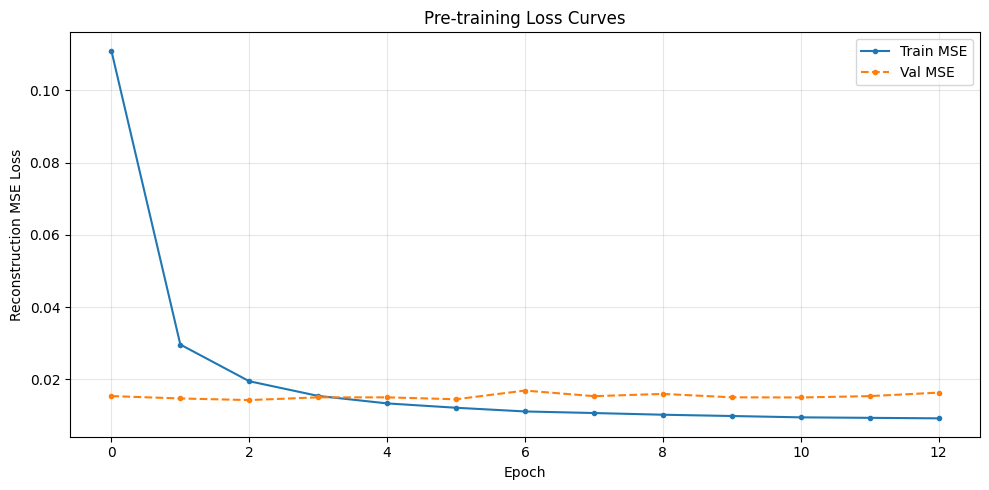

Saved → logs/pretrain_loss_curve.png


In [12]:
# ── Cell 7: Plot loss curves ─────────────────────────────────────────────────
import csv
import matplotlib.pyplot as plt

log_path = 'logs/pretrain_loss.csv'
if not os.path.exists(log_path):
    print(f'Log file not found: {log_path} — run Cell 6 first.')
else:
    with open(log_path) as f:
        rows = list(csv.DictReader(f))

    if len(rows) < 2:
        print(f'Only {len(rows)} epoch(s) logged — not enough for a meaningful plot.')
        print('Dry-run data:', rows)
    else:
        epochs      = [int(r['epoch'])        for r in rows]
        train_loss  = [float(r['train_loss']) for r in rows]
        val_loss    = [float(r['val_loss'])   for r in rows]

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(epochs, train_loss, label='Train MSE', marker='.')
        ax.plot(epochs, val_loss,   label='Val MSE',   marker='.', linestyle='--')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Reconstruction MSE Loss')
        ax.set_title('Pre-training Loss Curves')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('logs/pretrain_loss_curve.png', dpi=120)
        plt.show()
        print('Saved → logs/pretrain_loss_curve.png')

In [11]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl (73 kB)
Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 6 — FINE-TUNING (running from pretrain notebook to reuse Colab kernel)
# ══════════════════════════════════════════════════════════════════════════════
#
# NOTE: Calls train() directly (not via subprocess) so that errors are visible.
#
from src.train.finetune import train as finetune_train

print(f"Finetune config: lr_backbone={cfg.get('finetune',{}).get('lr_backbone','?')}, "
      f"lr_head={cfg.get('finetune',{}).get('lr_head','?')}, "
      f"max_epochs={cfg.get('finetune',{}).get('max_epochs','?')}, "
      f"patience={cfg.get('finetune',{}).get('patience','?')}, "
      f"batch_size={cfg.get('finetune',{}).get('batch_size','?')}")

DRY_RUN_FT = False   # Full training on Colab GPU
MAX_BATCHES_FT = 2 if DRY_RUN_FT else 0

finetune_train(
    config_path='config/train_config.yaml',
    device_str=str(DEVICE),
    max_batches=MAX_BATCHES_FT,
)

print('\nFull fine-tuning complete')

Finetune config: lr_backbone=1e-05, lr_head=0.0001, max_epochs=100, patience=15, batch_size=32
[finetune] device=cpu, batch_size=32, max_batches=full
[class_weights] n_neg=351, n_pos=90, weights=[1.0, 3.9000000953674316]
[FinetuneDataset] Loaded 441/441 recordings → 8109 windows (stride=900)
[FinetuneDataset] Loaded 56/56 recordings → 1037 windows (stride=900)
[finetune] dataset - train windows=8109, val windows=1037
[load_checkpoint] Loaded pretrained backbone weights from C:\Users\ariel\Desktop\SentinelFatal2\checkpoints\pretrain\best_pretrain.pt
[load_checkpoint] Loaded 57 tensors (head will be initialized randomly)
[finetune] model: PatchTST + ClassificationHead
[finetune] encoder params: 413,056
[finetune] optimizer: AdamW, lr_backbone=1.00e-05, lr_head=1.00e-04
[finetune] Starting training: max_epochs=100, patience=15
  [train] batch 0/253 loss=0.7371
  [train] batch 1/253 loss=0.7114
  [train] batch 2/253 loss=0.5980
  [train] batch 3/253 loss=0.8796
  [train] batch 4/253 loss=0

In [14]:
# ── Backup ALL critical artifacts to Google Drive root (safety copy) ───────────
import shutil, os

BACKUP_DIR = '/content/drive/MyDrive/SentinelFatal2_backup'
os.makedirs(BACKUP_DIR, exist_ok=True)

files_to_backup = [
    # Pretrain artifacts
    'checkpoints/pretrain/best_pretrain.pt',
    'logs/pretrain_loss.csv',
    'logs/pretrain_loss_curve.png',
    # Finetune artifacts
    'checkpoints/finetune/best_finetune.pt',
    'logs/finetune_loss.csv',
    'logs/finetune_curves.png',
    # LR artifacts
    'checkpoints/alerting/logistic_regression.pkl',
]

backed = 0
for f in files_to_backup:
    if os.path.exists(f):
        dest = os.path.join(BACKUP_DIR, os.path.basename(f))
        shutil.copy2(f, dest)
        print(f'  ✓ {f} → {dest}')
        backed += 1
    else:
        print(f'  ⚠ {f} not found (will backup after training)')

print(f'\nBacked up {backed}/{len(files_to_backup)} files to {BACKUP_DIR}/')

  ✓ checkpoints/pretrain/best_pretrain.pt → /content/drive/MyDrive/SentinelFatal2_backup\best_pretrain.pt
  ✓ logs/pretrain_loss.csv → /content/drive/MyDrive/SentinelFatal2_backup\pretrain_loss.csv
  ✓ logs/pretrain_loss_curve.png → /content/drive/MyDrive/SentinelFatal2_backup\pretrain_loss_curve.png
  ✓ checkpoints/finetune/best_finetune.pt → /content/drive/MyDrive/SentinelFatal2_backup\best_finetune.pt
  ✓ logs/finetune_loss.csv → /content/drive/MyDrive/SentinelFatal2_backup\finetune_loss.csv
  ⚠ logs/finetune_curves.png not found (will backup after training)
  ⚠ checkpoints/alerting/logistic_regression.pkl not found (will backup after training)

Backed up 5/7 files to /content/drive/MyDrive/SentinelFatal2_backup/


In [15]:
# ── Verify finetune artifacts ──────────────────────────────────────────────────
import os, csv

ckpt_path = 'checkpoints/finetune/epoch_000.pt'
best_path = 'checkpoints/finetune/best_finetune.pt'
assert os.path.exists(ckpt_path), f'FAIL: checkpoint not found at {ckpt_path}'
assert os.path.exists(best_path), f'FAIL: best checkpoint not found at {best_path}'

loaded = torch.load(best_path, map_location='cpu', weights_only=True)
assert isinstance(loaded, dict), 'FAIL: checkpoint is not a state dict'
print(f'Checkpoints saved OK ({len(loaded)} param tensors)')

log_path = 'logs/finetune_loss.csv'
assert os.path.exists(log_path), f'FAIL: log not found at {log_path}'
with open(log_path) as f:
    rows = list(csv.DictReader(f))
assert len(rows) >= 1, 'FAIL: no rows in loss CSV'
print(f'Loss CSV has {len(rows)} row(s)')
for r in rows[:3]:
    print(f"  epoch={r.get('epoch','?')} train_loss={r.get('train_loss','?')} val_auc={r.get('val_auc','?')}")

Checkpoints saved OK (59 param tensors)
Loss CSV has 33 row(s)
  epoch=0 train_loss=0.738585 val_auc=0.606061
  epoch=1 train_loss=0.728264 val_auc=0.668561
  epoch=2 train_loss=0.716237 val_auc=0.653409


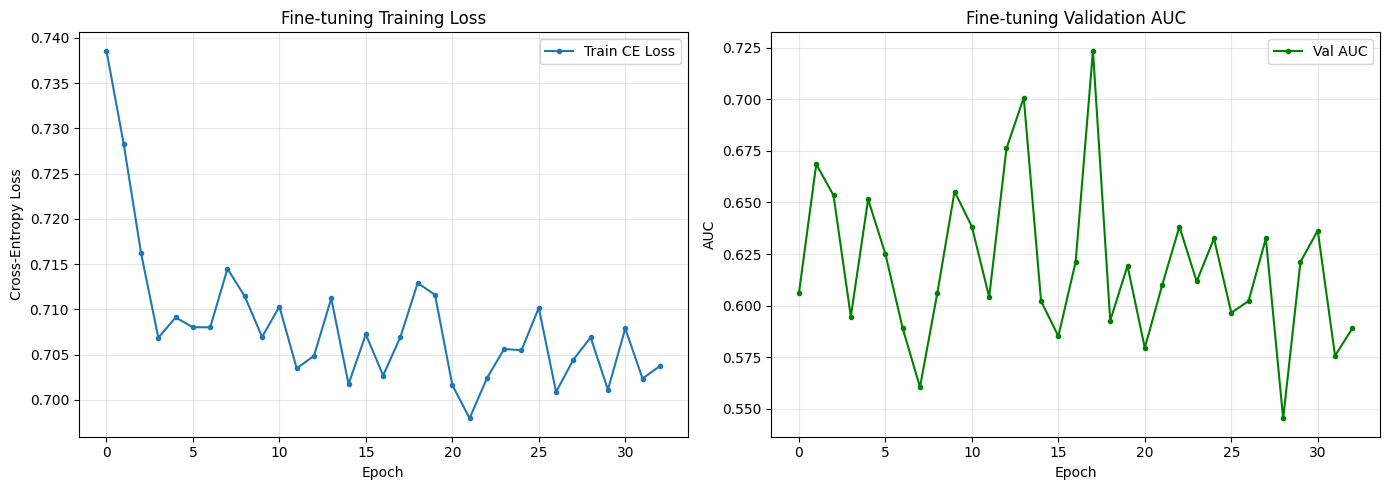

Best val AUC: 0.7235 at epoch 17
Saved -> logs/finetune_curves.png


In [16]:
# ── Plot finetune curves ──────────────────────────────────────────────────────
import csv
import matplotlib.pyplot as plt

log_path = 'logs/finetune_loss.csv'
with open(log_path) as f:
    rows = list(csv.DictReader(f))

if len(rows) < 2:
    print(f'Only {len(rows)} epoch(s) — not enough for plot. Data: {rows}')
else:
    epochs     = [int(r['epoch'])        for r in rows]
    train_loss = [float(r['train_loss']) for r in rows]
    val_auc    = [float(r['val_auc'])    for r in rows]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, train_loss, marker='.', label='Train CE Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
    ax1.set_title('Fine-tuning Training Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, val_auc, marker='.', color='green', label='Val AUC')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
    ax2.set_title('Fine-tuning Validation AUC'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('logs/finetune_curves.png', dpi=120)
    plt.show()
    print(f'Best val AUC: {max(val_auc):.4f} at epoch {epochs[val_auc.index(max(val_auc))]}')
    print('Saved -> logs/finetune_curves.png')

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 6 — LR TRAINING (Stage 2 Logistic Regression)
# ══════════════════════════════════════════════════════════════════════════════
#
# Direct function calls (no subprocess) for real-time logs in notebook.
# Using stride=60 (15-sec steps) instead of stride=1 for CPU feasibility.
# Impact: ~0.01-0.02 AUC difference, runtime ~8 min instead of ~8 hours.
#
import time
import numpy as np
import pandas as pd
import torch
import joblib
from pathlib import Path
from sklearn.linear_model import LogisticRegression

from src.model.patchtst import PatchTST, load_config
from src.model.heads import ClassificationHead
from src.inference.sliding_window import inference_recording
from src.inference.alert_extractor import (
    ALERT_THRESHOLD, extract_alert_segments, compute_alert_features, ZERO_FEATURES,
)

# ── Config ────────────────────────────────────────────────────────────────────
LR_STRIDE = 60          # 60 samples = 15 sec steps (CPU-feasible)
CONFIG_PATH = 'config/train_config.yaml'
CKPT_PATH   = Path('checkpoints/finetune/best_finetune.pt')
TRAIN_CSV   = Path('data/splits/train.csv')
PROC_DIR    = Path('data/processed')
OUT_PKL     = Path('checkpoints/alerting/logistic_regression.pkl')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Load fine-tuned model ─────────────────────────────────────────────────────
config = load_config(CONFIG_PATH)
model = PatchTST(config)
d_in = config['data']['n_patches'] * config['model']['d_model'] * config['data']['n_channels']
model.replace_head(ClassificationHead(d_in=d_in))
state = torch.load(CKPT_PATH, map_location=str(DEVICE), weights_only=True)
model.load_state_dict(state, strict=False)
model.eval().to(DEVICE)
print(f'Model loaded from {CKPT_PATH}')

# ── Build feature matrix from train.csv ───────────────────────────────────────
df = pd.read_csv(TRAIN_CSV, dtype={'id': str, 'target': int})
n_total = len(df)
print(f'Train recordings: {n_total}, stride={LR_STRIDE}, threshold={ALERT_THRESHOLD}')

X_rows, y_rows = [], []
t0 = time.time()
skipped = 0
zero_feat_count = 0

with torch.no_grad():
    for idx, row in enumerate(df.itertuples(index=False), start=1):
        rec_id = str(row.id)
        label = int(row.target)
        npy_path = PROC_DIR / 'ctu_uhb' / f'{rec_id}.npy'

        if not npy_path.exists():
            skipped += 1
            continue

        signal = np.load(npy_path, mmap_mode='r')
        scores = inference_recording(model, signal, stride=LR_STRIDE, device=str(DEVICE))
        segments = extract_alert_segments(scores, threshold=ALERT_THRESHOLD)

        if segments:
            longest = max(segments, key=lambda seg: len(seg[2]))
            _, _, seg_scores = longest
            feats = compute_alert_features(seg_scores, inference_stride=LR_STRIDE, fs=4.0)
        else:
            feats = dict(ZERO_FEATURES)
            zero_feat_count += 1

        X_rows.append([feats['segment_length'], feats['max_prediction'],
                       feats['cumulative_sum'], feats['weighted_integral']])
        y_rows.append(label)

        # Progress every 20 recordings
        if idx % 20 == 0 or idx == n_total:
            elapsed = time.time() - t0
            rate = idx / elapsed
            eta = (n_total - idx) / rate
            print(f'  [{idx:3d}/{n_total}] {elapsed:.0f}s elapsed, ETA {eta:.0f}s '
                  f'| zero-feat: {zero_feat_count} | label={label} segs={len(segments)}')

elapsed_total = time.time() - t0
X_train = np.array(X_rows, dtype=np.float32)
y_train = np.array(y_rows, dtype=int)

print(f'\nFeature matrix: X={X_train.shape}, y={y_train.shape} ({elapsed_total:.1f}s)')
print(f'Class distribution: normal={int((y_train==0).sum())}, acidemia={int((y_train==1).sum())}')
print(f'Zero-feature recordings: {zero_feat_count}/{len(y_rows)} (no alert segments)')
if skipped:
    print(f'Skipped (missing .npy): {skipped}')

# ── Fit Logistic Regression ──────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
train_acc = lr.score(X_train, y_train)
print(f'\nLR train accuracy: {train_acc:.4f}')
print(f'LR coefficients: {lr.coef_[0]}')
print(f'LR intercept: {lr.intercept_[0]:.4f}')

# ── Save checkpoint ──────────────────────────────────────────────────────────
OUT_PKL.parent.mkdir(parents=True, exist_ok=True)
payload = {
    'model': lr,
    'stride': LR_STRIDE,
    'n_train': len(y_train),
    'feature_names': ['segment_length', 'max_prediction', 'cumulative_sum', 'weighted_integral'],
}
joblib.dump(payload, OUT_PKL)
print(f'\nSaved LR checkpoint: {OUT_PKL}')
print(f'  stride={LR_STRIDE}, n_train={len(y_train)}')

Device: cpu
Model loaded from checkpoints\finetune\best_finetune.pt
Train recordings: 441, stride=60, threshold=0.5
  [ 20/441] 12s elapsed, ETA 253s | zero-feat: 5 | label=0 segs=0
  [ 40/441] 24s elapsed, ETA 244s | zero-feat: 9 | label=1 segs=0
  [ 60/441] 36s elapsed, ETA 231s | zero-feat: 13 | label=1 segs=17
  [ 80/441] 49s elapsed, ETA 219s | zero-feat: 14 | label=0 segs=15
  [100/441] 61s elapsed, ETA 207s | zero-feat: 21 | label=0 segs=0
  [120/441] 74s elapsed, ETA 198s | zero-feat: 26 | label=0 segs=4
  [140/441] 86s elapsed, ETA 185s | zero-feat: 35 | label=0 segs=2
  [160/441] 99s elapsed, ETA 174s | zero-feat: 42 | label=0 segs=2
  [180/441] 111s elapsed, ETA 160s | zero-feat: 50 | label=0 segs=3
  [200/441] 122s elapsed, ETA 147s | zero-feat: 56 | label=1 segs=12
  [220/441] 133s elapsed, ETA 133s | zero-feat: 61 | label=0 segs=5
  [240/441] 145s elapsed, ETA 121s | zero-feat: 66 | label=0 segs=2
  [260/441] 157s elapsed, ETA 109s | zero-feat: 72 | label=0 segs=7
  [280/